## LSTM vs GRU

**Plan:**
1. Imports and setup
2. Train and eval data
3. Search over both LSTM and GRU with a wide parameter range 
4. Results
5. Predict 200 points
6. Show difference in predictions

In [2]:
%pip install torch numpy scipy scikit-learn matplotlib pandas

  Using cached torch-2.11.0-cp314-cp314-win_amd64.whl.metadata (29 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
Using cached torch-2.11.0-cp314-cp314-win_amd64.whl (114.6 MB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   ---------------------------------------- 0/5 [jinja2]
   ---------------------------------------- 0/5 [jinja2]
   ---------------------------------------- 0/5 [jinja2]
   -------- ------------------------------- 1/5 [contourpy]
   ---------------- ----------------------- 2/5 [torch]
   ---------------- ------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports and setup

In [3]:
from scipy import io
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import numpy.typing as npt
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

mat_data: dict = io.loadmat('Xtrain.mat')
data: npt.NDArray[np.float64] = mat_data['Xtrain'].flatten()

scaler: MinMaxScaler = MinMaxScaler()
data_scaled: npt.NDArray[np.float64] = scaler.fit_transform(data.reshape(-1, 1)).flatten()

print(f"Loaded {len(data)} samples")

Loaded 1000 samples


## 2. Setup

In [4]:
def create_intervals(
    data: npt.NDArray[np.float64],
    interval_size: int,
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """Slice time series into (x, y) pairs for supervised learning."""
    x: list[npt.NDArray[np.float64]] = []
    y: list[np.float64] = []
    for i in range(len(data) - interval_size):
        x.append(data[i:i + interval_size])
        y.append(data[i + interval_size])
    return np.array(x), np.array(y)


device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 3. Model definitions

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size: int, hidden_size: int) -> None:
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class GRUModel(nn.Module):
    def __init__(self, input_size: int, hidden_size: int) -> None:
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

## 4. Training with validation

In [6]:
from typing import Type

def train_and_evaluate(
    x: npt.NDArray[np.float64],
    y: npt.NDArray[np.float64],
    model_class: Type[nn.Module],
    hidden_size: int,
    learning_rate: float,
    loss_fn: nn.Module | None = None,
    nepoch: int = 40,
    val_split: float = 0.2,
) -> tuple[nn.Module, float]:
    if loss_fn is None:
        loss_fn = nn.MSELoss()

    split: int = int(len(x) * (1 - val_split))
    x_train, x_val = x[:split], x[split:]
    y_train, y_val = y[:split], y[split:]

    x_train_t: torch.Tensor = torch.tensor(x_train, dtype=torch.float32).unsqueeze(-1).to(device)
    y_train_t: torch.Tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1).to(device)
    x_val_t:   torch.Tensor = torch.tensor(x_val,   dtype=torch.float32).unsqueeze(-1).to(device)
    y_val_t:   torch.Tensor = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(-1).to(device)

    model: nn.Module = model_class(1, hidden_size).to(device)
    optimizer: optim.Adam = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(nepoch):
        model.train()
        optimizer.zero_grad()
        output: torch.Tensor = model(x_train_t)
        loss: torch.Tensor = loss_fn(output, y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss: float = loss_fn(model(x_val_t), y_val_t).item()

    return model, val_loss

## 5. Grid search

Wide parameter ranges so we can see the way that it influences the model.

In [7]:
interval_sizes: list[int]   = [2, 5, 10, 20, 30, 50]
hidden_sizes: list[int]     = [4, 8, 16, 32, 64]
learning_rates: list[float] = [0.0001, 0.001, 0.01, 0.05, 0.1]
model_classes: list[tuple[str, Type[nn.Module]]]   = [("LSTM", LSTMModel), ("GRU", GRUModel)]
loss_functions: list[tuple[str, nn.Module]]  = [("MSE", nn.MSELoss()), ("MAE", nn.L1Loss())]

results: list[dict] = []
all_models: list[tuple[dict, nn.Module]] = []
best_val_loss: float = float("inf")
best_config: tuple[str, str, int, int, float] | None = None
best_model: nn.Module | None = None

total: int = len(model_classes) * len(interval_sizes) * len(hidden_sizes) * len(learning_rates) * len(loss_functions)
count: int = 0

for model_name, model_class in model_classes:
    for interval in interval_sizes:
        x, y = create_intervals(data_scaled, interval)
        for hsize in hidden_sizes:
            for lr in learning_rates:
                for loss_name, loss_fn in loss_functions:
                    count += 1
                    try:
                        model, val_loss = train_and_evaluate(x, y, model_class, hsize, lr, loss_fn=loss_fn)
                        config: dict = {
                            "model":       model_name,
                            "loss_fn":     loss_name,
                            "interval":    interval,
                            "hidden_size": hsize,
                            "lr":          lr,
                            "val_loss":    round(val_loss, 6)
                        }
                        results.append(config)
                        all_models.append((config, model))

                        if val_loss < best_val_loss:
                            best_val_loss = val_loss
                            best_config = (model_name, loss_name, interval, hsize, lr)
                            best_model = model

                        if count % 20 == 0:
                            print(f"Progress: {count}/{total}")
                    except Exception as e:
                        print(f"Failed: model={model_name} loss={loss_name} interval={interval} hsize={hsize} lr={lr} - {e}")


all_models.sort(key=lambda x: x[0]["val_loss"])
top_20: list[tuple[dict, nn.Module]] = all_models[:20]

print(f"Done. Best config: {best_config} | val_loss={best_val_loss:.6f}")

Progress: 20/600
Progress: 40/600
Progress: 60/600
Progress: 80/600
Progress: 100/600
Progress: 120/600
Progress: 140/600
Progress: 160/600
Progress: 180/600
Progress: 200/600
Progress: 220/600
Progress: 240/600
Progress: 260/600
Progress: 280/600
Progress: 300/600
Progress: 320/600
Progress: 340/600
Progress: 360/600
Progress: 380/600
Progress: 400/600
Progress: 420/600
Progress: 440/600
Progress: 460/600
Progress: 480/600
Progress: 500/600
Progress: 520/600
Progress: 540/600
Progress: 560/600
Progress: 580/600
Progress: 600/600
Done. Best config: ('GRU', 'MSE', 30, 64, 0.01) | val_loss=0.001463


## 6. Results table

In [8]:
df: pd.DataFrame = pd.DataFrame(results)
df_sorted: pd.DataFrame = df.sort_values("val_loss")

print("------------- Top 20 ------------")
print(df_sorted.head(20).to_string(index=False))

print("\n------------- Worst 10 -------------")
print(df_sorted.tail(10).to_string(index=False))


best_per_combination = df_sorted.drop_duplicates(subset=['model', 'loss_fn'], keep='first')
print("Best results per Model + Loss Function combination:\n")
print(best_per_combination.to_string(index=False))

------------- Top 20 ------------
model loss_fn  interval  hidden_size   lr  val_loss
  GRU     MSE        30           64 0.01  0.001463
 LSTM     MSE        20            8 0.10  0.001712
  GRU     MSE        20           32 0.05  0.001777
 LSTM     MSE        20            4 0.05  0.002017
  GRU     MSE        20            8 0.05  0.002241
  GRU     MSE        10           32 0.05  0.002259
 LSTM     MSE        50           32 0.05  0.002291
  GRU     MSE        30           32 0.10  0.002424
  GRU     MSE        50            4 0.05  0.002480
 LSTM     MSE         5            8 0.05  0.002734
  GRU     MSE        20            4 0.05  0.003070
  GRU     MSE         5           16 0.05  0.003158
  GRU     MSE        30           16 0.05  0.003212
 LSTM     MSE        30           16 0.05  0.003317
  GRU     MSE         5            8 0.10  0.003402
  GRU     MSE        50           16 0.05  0.003629
 LSTM     MSE        10           16 0.05  0.003704
  GRU     MSE        30       

## 7. Summary: effect of each parameter

In [9]:
print("Average val_loss per model:")
print(df.groupby("model")["val_loss"].mean().round(6).to_string())

print("\nAverage val_loss per loss function:")
print(df.groupby("loss_fn")["val_loss"].mean().round(6).to_string())
# Note: MSE values are squared so it seems they're always smaller than MAE values. I should look up if I can scale this so that they're comparable. 

print("\nAverage val_loss per interval_size:")
print(df.groupby("interval")["val_loss"].mean().round(6).to_string())

print("\nAverage val_loss per hidden_size:")
print(df.groupby("hidden_size")["val_loss"].mean().round(6).to_string())

print("\nAverage val_loss per learning_rate:")
print(df.groupby("lr")["val_loss"].mean().round(6).to_string())

Average val_loss per model:
model
GRU     0.088288
LSTM    0.094339

Average val_loss per loss function:
loss_fn
MAE    0.138207
MSE    0.044420

Average val_loss per interval_size:
interval
2     0.085811
5     0.087575
10    0.093546
20    0.088762
30    0.100643
50    0.091543

Average val_loss per hidden_size:
hidden_size
4     0.124627
8     0.103009
16    0.078448
32    0.069544
64    0.080938

Average val_loss per learning_rate:
lr
0.0001    0.191029
0.0010    0.111987
0.0100    0.052285
0.0500    0.041202
0.1000    0.060063


## 8. Predict 200 steps with best model

In [10]:
data_real: npt.NDArray[np.float64] = io.loadmat("Xtrain.mat")["Xtrain"].flatten()

top_20_preds: list[npt.NDArray[np.float64]] = []

for config, model in top_20:
    interval: int = config["interval"]
    input_sequence: npt.NDArray[np.float64] = data_scaled[-interval:].copy()
    pred_list: list[float] = []

    model.eval()
    for step in range(200):
        x: torch.Tensor = torch.tensor(input_sequence, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
        with torch.no_grad():
            pred: float = model(x).item()
        pred_list.append(pred)
        input_sequence = np.append(input_sequence[1:], pred)

    pred_scaled_back: npt.NDArray[np.float64] = scaler.inverse_transform(np.array(pred_list).reshape(-1, 1)).flatten()
    top_20_preds.append(pred_scaled_back)

# Also save the best one separately
best_preds: npt.NDArray[np.float64] = top_20_preds[0]
np.savetxt("200predictions.csv", best_preds, delimiter=",")
print("Saved 200predictions.csv (best model)")


# and the top one separately for easy access
best_interval: int = best_config[2]

input_sequence = data_scaled[-best_interval:].copy()
preds: list[float] = []

best_model.eval()
for step in range(200):
    x = torch.tensor(input_sequence, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
    with torch.no_grad():
        pred = best_model(x).item()
    preds.append(pred)
    input_sequence = np.append(input_sequence[1:], pred)

preds_array: npt.NDArray[np.float64] = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

Saved 200predictions.csv (best model)


## 9. Evaluate and plot

Best model: {'model': 'GRU', 'loss_fn': 'MSE', 'interval': 30, 'hidden_size': 64, 'lr': 0.01, 'val_loss': 0.001463}
MAE:  63.9777. Average error per step in original units
MSE:  6192.2571. Same but large errors count more (squared)
RMSE: 78.6909. MSE back in the same unit as the data


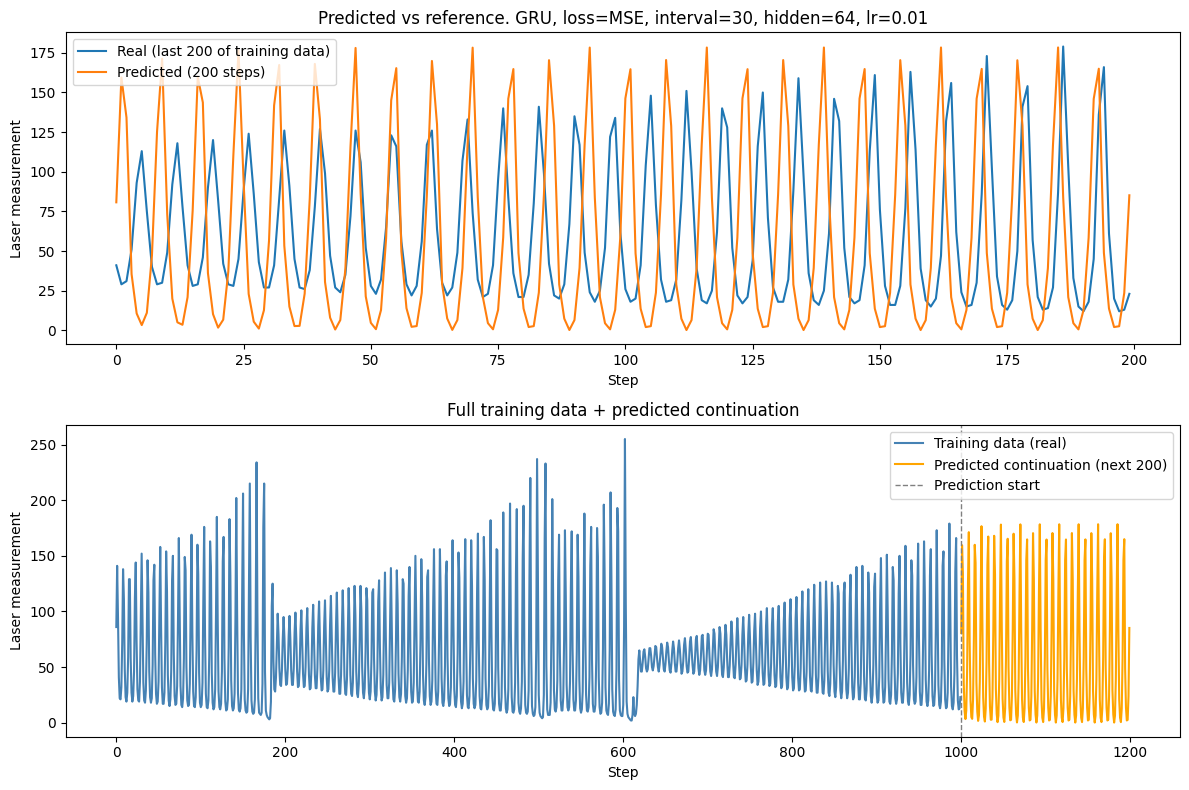

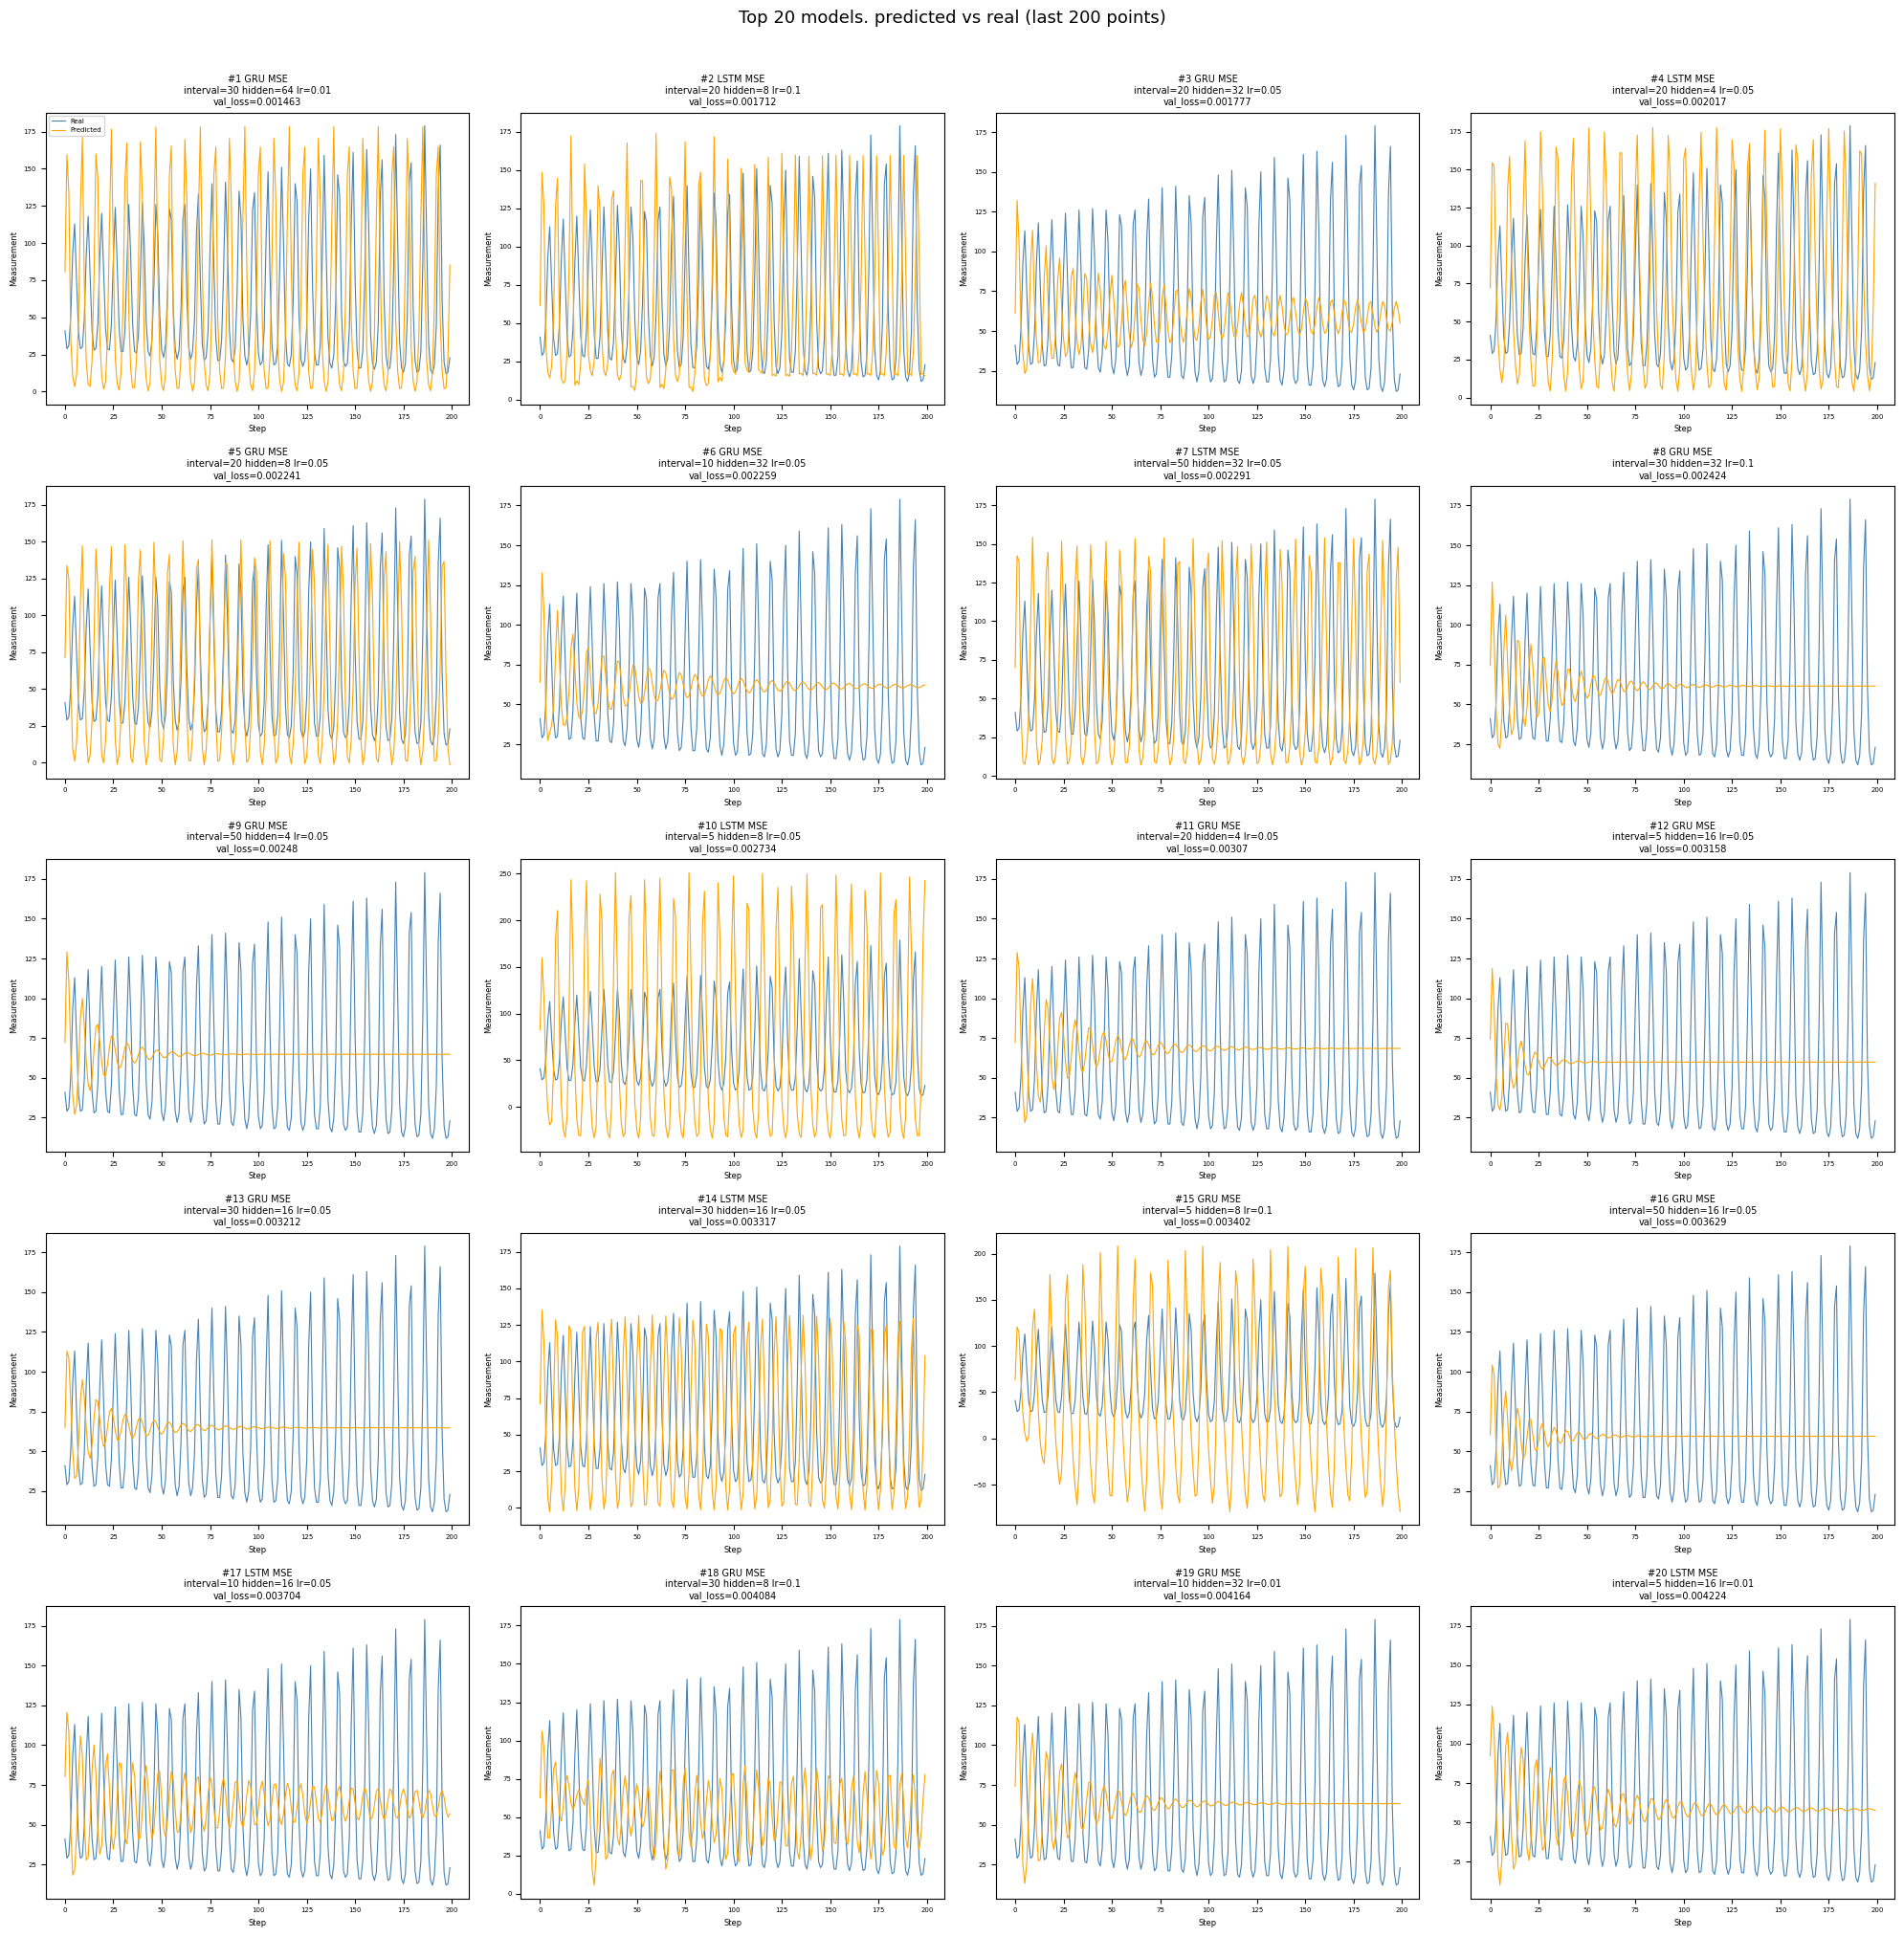

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.axes

reference: npt.NDArray[np.float64] = data_real[-200:]
continuation_x: npt.NDArray[np.intp] = np.arange(len(data_real), len(data_real) + 200)

# Best model metrics
best_preds = top_20_preds[0]
best_cfg: dict = top_20[0][0]
mae: float = mean_absolute_error(reference, best_preds)
mse: float = mean_squared_error(reference, best_preds)

print(f"Best model: {best_cfg}")
print(f"MAE:  {mae:.4f}. Average error per step in original units")
print(f"MSE:  {mse:.4f}. Same but large errors count more (squared)")
print(f"RMSE: {mse**0.5:.4f}. MSE back in the same unit as the data")



# predictions vs the last 200 real points
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(reference, label="Real (last 200 of training data)")
axes[0].plot(preds_array, label="Predicted (200 steps)")
axes[0].set_title(
    f"Predicted vs reference. {best_config[0]}, loss={best_config[1]}, "
    f"interval={best_config[2]}, hidden={best_config[3]}, lr={best_config[4]}"
)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Laser measurement")
axes[0].legend()

# full training data with predicted continuation appended
continuation_x = np.arange(len(data_real), len(data_real) + 200)

axes[1].plot(np.arange(len(data_real)), data_real, label="Training data (real)", color="steelblue")
axes[1].plot(continuation_x, preds_array, label="Predicted continuation (next 200)", color="orange")
axes[1].axvline(x=len(data_real), color="gray", linestyle="--", linewidth=1, label="Prediction start")
axes[1].set_title("Full training data + predicted continuation")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Laser measurement")
axes[1].legend()

plt.tight_layout()
plt.show()

# Top 20
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes_flat: npt.NDArray = axes.flatten()

for i, (ax, (config, _)) in enumerate(zip(axes_flat, top_20)):
    preds_i: npt.NDArray[np.float64] = top_20_preds[i]
    ax.plot(reference, color="steelblue", linewidth=0.8, label="Real")
    ax.plot(preds_i, color="orange", linewidth=0.8, label="Predicted")
    ax.set_title(
        f"#{i+1} {config['model']} {config['loss_fn']}\n"
        f"interval={config['interval']} hidden={config['hidden_size']} lr={config['lr']}\n"
        f"val_loss={config['val_loss']}",
        fontsize=7
    )
    ax.set_xlabel("Step", fontsize=6)
    ax.set_ylabel("Measurement", fontsize=6)
    ax.tick_params(labelsize=5)
    if i == 0:
        ax.legend(fontsize=5)

plt.suptitle("Top 20 models. predicted vs real (last 200 points)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Test Data

MAE: 49.7012460558489
MSE: 4102.712594979148


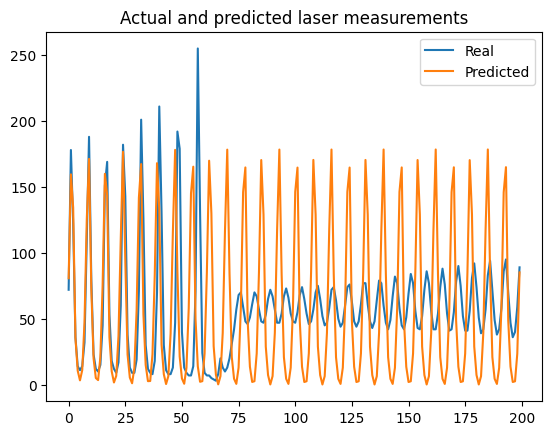

In [15]:
test_data = io.loadmat("Xtest.mat")
yreal: npt.NDArray[np.float64] = test_data["Xtest"].flatten()

# compare 200 predictions with first 200 real values
y_true = yreal[:len(preds_array)]

mae = mean_absolute_error(y_true, preds_array)
mse = mean_squared_error(y_true, preds_array)

print(f"MAE: {mae}")
print(f"MSE: {mse}")

# plot
plt.figure()
plt.plot(y_true, label="Real")
plt.plot(preds_array, label="Predicted")
plt.legend()
plt.title("Actual and predicted laser measurements")
plt.show()